# Problema das Vigas

Duas vigas (30 m e 20 m) se cruzam a 8 m do chão. Com $a=\sqrt{30^2-x^2}$ e $b=\sqrt{20^2-x^2}$:

$$f(x)=\frac{1}{\sqrt{900-x^2}}+\frac{1}{\sqrt{400-x^2}}-\frac{1}{8}=0$$

**Restrição física:** $0<x<20$ (a viga de 20 m precisa alcançar a parede).

**Critério de parada:** $|x_{k+1}-x_k|<10^{-6}$ (ou $b-a<10^{-6}$), máx. 100 iterações. Precisão de micrômetros é mais que suficiente para uma medida de galpão e está bem acima do erro de arredondamento do `float`.

In [1]:
from metodos_raizes import f, df, g, bissecao, posicao_falsa, ponto_fixo, secante, newton_raphson
import numpy as np, pandas as pd, matplotlib.pyplot as plt
TOL = 1e-6

## Isolamento da raiz

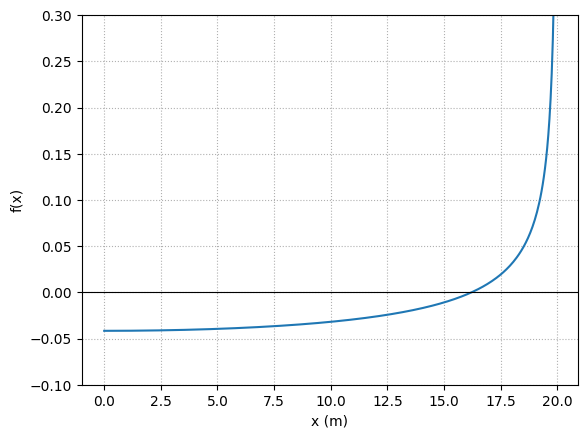

f(10) = -0.03190963402171006  f(18) = 0.03137453360194753


In [2]:
xs = np.linspace(0, 19.9, 400)
plt.plot(xs, [f(x) for x in xs]); plt.axhline(0, color='k', lw=.8)
plt.ylim(-0.1, 0.3); plt.xlabel('x (m)'); plt.ylabel('f(x)'); plt.grid(ls=':'); plt.show()
print('f(10) =', f(10), ' f(18) =', f(18))

## Execução dos métodos

In [3]:
resultados = {
    'Bisseção [10, 18]':       bissecao(f, 10, 18, TOL),
    'Posição Falsa [10, 18]':  posicao_falsa(f, 10, 18, TOL),
    'Ponto Fixo x0=15':        ponto_fixo(g, 15, TOL),
    'Secante x0=15, x1=17':    secante(f, 15, 17, TOL),
    'Newton-Raphson x0=15':    newton_raphson(f, df, 15, TOL),
}
for nome, (raiz, hist) in resultados.items():
    print(f'\n=== {nome} ===')
    display(pd.DataFrame(hist))


=== Bisseção [10, 18] ===


,k,a,b,x,f(x),erro
0,1,10.000000,18.000000,14.000000,-1.729708e-02,8.000000
1,2,14.000000,18.000000,16.000000,-2.261146e-03,4.000000
2,3,16.000000,18.000000,17.000000,1.037147e-02,2.000000
3,4,16.000000,17.000000,16.500000,3.387080e-03,1.000000
4,5,16.000000,16.500000,16.250000,4.235306e-04,0.500000
5,6,16.000000,16.250000,16.125000,-9.509046e-04,0.250000
6,7,16.125000,16.250000,16.187500,-2.720318e-04,0.125000
7,8,16.187500,16.250000,16.218750,7.362110e-05,0.062500
8,9,16.187500,16.218750,16.203125,-9.973205e-05,0.031250
9,10,16.203125,16.218750,16.210938,-1.318782e-05,0.015625



=== Posição Falsa [10, 18] ===


,k,a,b,x,f(x),erro
0,1,10.000000,18,14.033822,-1.710840e-02,4.033822e+00
1,2,14.033822,18,15.433386,-7.514949e-03,1.399564e+00
2,3,15.433386,18,15.929355,-2.975087e-03,4.959690e-01
3,4,15.929355,18,16.108697,-1.125322e-03,1.793426e-01
4,5,16.108697,18,16.174184,-4.180419e-04,6.548721e-02
5,6,16.174184,18,16.198192,-1.542411e-04,2.400772e-02
6,7,16.198192,18,16.207007,-5.676491e-05,8.814577e-03
7,8,16.207007,18,16.210245,-2.087151e-05,3.238145e-03
8,9,16.210245,18,16.211435,-7.671463e-06,1.189820e-03
9,10,16.211435,18,16.211872,-2.819341e-06,4.372195e-04



=== Ponto Fixo x0=15 ===


,k,x,erro
0,1,16.321189,1.321189e+00
1,2,16.201125,1.200641e-01
2,3,16.213224,1.209899e-02
3,4,16.212016,1.207418e-03
4,5,16.212137,1.206120e-04
5,6,16.212125,1.204706e-05
6,7,16.212126,1.203306e-06
7,8,16.212126,1.201906e-07



=== Secante x0=15, x1=17 ===


,k,x,f(x),erro
0,1,16.025630,-1.997489e-03,9.743704e-01
1,2,16.182983,-3.216498e-04,1.573531e-01
2,3,16.213184,1.174788e-05,3.020134e-02
3,4,16.212120,-6.688142e-08,1.064200e-03
4,5,16.212126,-1.383602e-11,6.024261e-06
5,6,16.212126,2.775558e-17,1.246519e-09



=== Newton-Raphson x0=15 ===


,k,x,f(x),erro
0,1,16.488411,3.242849e-03,1.488411e+00
1,2,16.227219,1.680241e-04,2.611924e-01
2,3,16.212170,4.946099e-07,1.504844e-02
3,4,16.212126,4.308692e-12,4.455976e-05
4,5,16.212126,0.000000e+00,3.881802e-10


## Comparação

,Método,Raiz x (m),Iterações,|f(x)|
0,"Bisseção [10, 18]",16.212127,23,9.270283e-09
1,"Posição Falsa [10, 18]",16.212126,17,2.551696e-09
2,Ponto Fixo x0=15,16.212126,8,1.211520e-10
3,"Secante x0=15, x1=17",16.212126,6,2.775558e-17
4,Newton-Raphson x0=15,16.212126,5,0.000000e+00


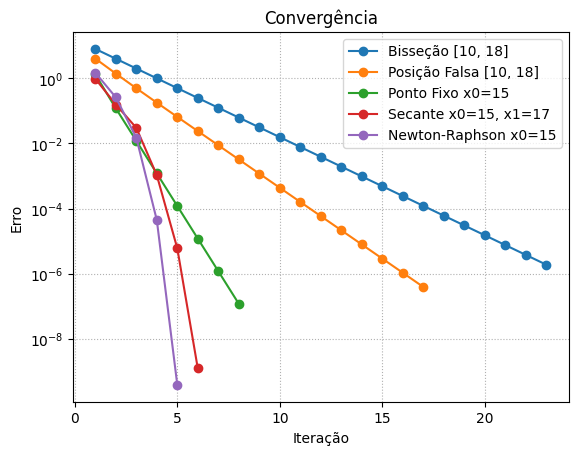

In [4]:
tabela = pd.DataFrame([{'Método': n, 'Raiz x (m)': r, 'Iterações': len(h), '|f(x)|': abs(f(r))}
                       for n, (r, h) in resultados.items()])
display(tabela)

for n, (r, h) in resultados.items():
    plt.semilogy([e['k'] for e in h], [max(e['erro'], 1e-16) for e in h], 'o-', label=n)
plt.xlabel('Iteração'); plt.ylabel('Erro'); plt.title('Convergência'); plt.legend(); plt.grid(ls=':'); plt.show()

## Conclusão

A largura do galpão é **x ≈ 16,2121 m**. Newton-Raphson e Secante convergem em poucas iterações (ordem 2 e ~1,6); Ponto Fixo converge linearmente; Bisseção é robusta porém lenta; a Posição Falsa fica com um extremo fixo devido à convexidade de f, convergindo mais devagar quando o intervalo se aproxima de 20.